# Batch EDA — 품질 점검과 열화 곡선

원본 값·cycle 번호·셀 항목을 보존하며, 분석용 열을 따로 만듭니다. 먼저 조건 셀에서 Batch를 선택하고 위에서부터 전체 실행하세요. 커널은 프로젝트 `.venv`를 사용합니다.

처리 원칙: QD와 IR의 비유한값·0 이하 값은 해당 변수의 분석용 열에서만 NaN으로 가립니다. 높은 QD는 검토 플래그만 붙이며 선택적으로 가릴 수 있습니다. 낮은 양의 QD, 수명 누락 셀, 수명 이후 기록은 보존합니다. NaN으로 가린 점에서는 선이 끊겨 제외 구간을 연결하지 않습니다.

In [1]:
from pathlib import Path
import sys, importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

cwd = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in [cwd, *cwd.parents]
                     if (p / "src/load_data.py").is_file()
                     and (p / "requirements.txt").is_file()), None)
if PROJECT_ROOT is None:
    raise RuntimeError("프로젝트 디렉토리에서 실행하세요.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from src import load_data, preprocess, eda
for module in [load_data, preprocess, eda]:
    importlib.reload(module)
print("Python:", sys.executable)

Matplotlib is building the font cache; this may take a moment.


Python: /Users/soobin/myfolder/workspace/mini-project-data-analysis/.venv/bin/python


## 1. 분석 조건

`BATCH_NAME`을 바꾸면 선택한 Batch의 상세 결과를 확인할 수 있습니다. `MASK_HIGH_QD`를 바꾸면 높은 용량값을 가렸을 때 곡선이 어떻게 달라지는지 비교합니다. 1.32 Ah 초과 기준은 **1.1 Ah × 1.2라는 검토용 기준**이며 측정 오류 판정이 아닙니다. EOL 참조선은 1.1 Ah × 0.8 = 0.88 Ah이며 초기 용량의 비율과 구분합니다.

In [2]:
BATCH_NAME = "batch1"
EARLY_END = 100
MASK_HIGH_QD = False
SAVE_FIGURES = True
# 수동 대표 셀 지정: None이면 수명 그룹 중앙값에 가장 가까운 셀 선택
MANUAL_CELL_IDS = None  # 예: [0, 18, 22]
config = preprocess.QualityConfig(mask_high_qd=MASK_HIGH_QD)
DATA_DIR = PROJECT_ROOT / "data/raw"
path = load_data.batch_path(BATCH_NAME, DATA_DIR)
cells, raw, loader_quality = load_data.load_batch(path, BATCH_NAME)
prepared = preprocess.prepare_summary(raw, config)
diagnostics = preprocess.cell_diagnostics(cells, prepared, config)
assert len(raw) == len(prepared)
pd.testing.assert_frame_equal(raw, prepared[raw.columns])
display(pd.Series(prepared.attrs["quality_config"]).to_frame("value"))

,value
nominal_capacity_ah,1.1
eol_fraction,0.8
high_qd_factor,1.2
mask_high_qd,False


## 2. 특이값과 처리 규모

플래그는 한 행에 여러 개가 붙을 수 있으므로 합계를 제거 행 수로 읽지 않습니다. 모든 원본 행은 유지됩니다. QD·IR 분석용 값만 필요한 위치에서 가립니다.

In [3]:
flags = [k for k in prepared if k.startswith("flag_")]
display(prepared[flags].sum().to_frame("flagged_rows"))
display(pd.Series({"raw_rows": len(raw), "preserved_rows": len(prepared),
                   "QD_masked": prepared.QD_analysis.isna().sum(),
                   "IR_masked": prepared.IR_analysis.isna().sum(),
                   "cells_with_missing_or_invalid_life": diagnostics.flag_life_invalid_rows.gt(0).sum()
                  }).to_frame("count"))
issue_rows = prepared.loc[prepared.flag_qd_invalid | prepared.flag_qd_high |
                          prepared.flag_ir_invalid | prepared.flag_cycle_invalid |
                          prepared.flag_cycle_duplicate]
display(issue_rows[["cell_id", "cycle", "QD", "QD_analysis", "IR", "IR_analysis",
                    "flag_all_measurements_zero", "flag_qd_high"]].head(60))
display(diagnostics.loc[diagnostics.flag_life_invalid_rows.gt(0),
                        ["cell_id", "cycle_life", "raw_rows", "last_valid_QD"]])

,flagged_rows
flag_cycle_invalid,0
flag_cycle_duplicate,0
flag_life_invalid,0
flag_after_life,0
flag_qd_invalid,46
flag_qd_high,2
flag_ir_invalid,65
flag_all_measurements_zero,46


,count
raw_rows,38811
preserved_rows,38811
QD_masked,46
IR_masked,65
cells_with_missing_or_invalid_life,0


,cell_id,cycle,QD,QD_analysis,IR,IR_analysis,flag_all_measurements_zero,flag_qd_high
0,0,1.0,0.000000,NaN,0.000000,NaN,True,False
11,0,12.0,1.539054,1.539054,0.018950,0.018950,False,True
852,0,853.0,1.048792,1.048792,0.000000,NaN,False,False
1189,1,1.0,0.000000,NaN,0.000000,NaN,True,False
1200,1,12.0,1.084590,1.084590,0.000000,NaN,False,False
2038,1,850.0,1.050883,1.050883,0.000000,NaN,False,False
2367,2,1.0,0.000000,NaN,0.000000,NaN,True,False
2378,2,12.0,1.088054,1.088054,0.000000,NaN,False,False
3214,2,848.0,1.062176,1.062176,0.000000,NaN,False,False
3543,3,1.0,0.000000,NaN,0.000000,NaN,True,False


,cell_id,cycle_life,raw_rows,last_valid_QD


## 3. 용량 스파이크의 주변 회차

높은 QD값 앞뒤의 원본을 확인합니다. 임계값 초과만으로 원인을 확정하지 않습니다. 비교 대상이 많으면 처음 다섯 건의 주변만 표시합니다.

In [4]:
neighborhoods = []
for row in prepared.loc[prepared.flag_qd_high].head(5).itertuples():
    neighborhood = prepared.loc[prepared.cell_id.eq(row.cell_id) &
                                prepared.cycle.between(row.cycle - 2, row.cycle + 2),
                                ["cell_id", "cycle", "QD", "QC", "IR", "Tavg", "flag_qd_high"]].copy()
    neighborhood.insert(0, "center_cycle", row.cycle)
    neighborhoods.append(neighborhood)
if neighborhoods:
    display(pd.concat(neighborhoods, ignore_index=True))
else:
    print("No QD values above the configured review threshold.")

,center_cycle,cell_id,cycle,QD,QC,IR,Tavg,flag_qd_high
0,12.0,0,10.0,1.074537,1.074353,0.016572,31.841053,False
1,12.0,0,11.0,1.074781,1.074645,0.016565,31.811382,False
2,12.0,0,12.0,1.539054,1.546792,0.018950,30.282579,True
3,12.0,0,13.0,1.073827,1.071022,0.016630,31.541207,False
4,12.0,0,14.0,1.075056,1.073431,0.016624,31.554487,False
5,40.0,18,38.0,1.069573,1.940414,0.019886,31.711616,False
6,40.0,18,39.0,1.069454,1.967910,0.019886,31.829604,False
7,40.0,18,40.0,2.884085,2.965895,0.019886,30.761674,True
8,40.0,18,41.0,1.069482,1.069111,0.019886,31.580949,False
9,40.0,18,42.0,1.069463,1.069037,0.019886,31.562498,False


## 4. 수명과 기록 길이, 용량 기준 도달 회차

`first_observed_cycle_le_eol`은 유효한 양의 QD가 0.88 Ah 이하인 첫 **관측 cycle**입니다. 최초 0값은 이 계산에서 빠집니다. 잡음·기록 종료·기준 도달 여부에 따라 이 숫자와 수명 값은 다를 수 있으므로 타깃을 덮어쓰지 않습니다.

원 저자의 [MATLAB 처리 예시](https://github.com/rdbraatz/data-driven-prediction-of-battery-cycle-life-before-capacity-degradation/blob/master/LoadData.m)는 0.88 Ah 도달과 일부 실험 연장 처리를 사용합니다. 그러나 그 예시의 두 번째 파일은 2017-06-30이며, 우리의 2018-02-20 파일과 다릅니다. 해당 셀 인덱스를 현재 Batch 2에 그대로 적용하지 않습니다.

In [5]:
display(diagnostics[["cell_id", "cycle_life", "cycle_max", "record_end_minus_life",
                     "first_observed_cycle_le_eol", "crossing_minus_life", "last_valid_QD"]])
known_crossing = diagnostics.loc[np.isfinite(diagnostics.cycle_life) &
                                 np.isfinite(diagnostics.first_observed_cycle_le_eol)]
print("Observed crossings with known life:", len(known_crossing))
print("Crossing matches stored life:", known_crossing.crossing_minus_life.eq(0).sum())
print("Known-life cells without an observed crossing:",
      (np.isfinite(diagnostics.cycle_life) &
       diagnostics.first_observed_cycle_le_eol.isna()).sum())

,cell_id,cycle_life,cycle_max,record_end_minus_life,first_observed_cycle_le_eol,crossing_minus_life,last_valid_QD
0,0,1190.0,1189.0,-1.0,NaN,NaN,1.026210
1,1,1179.0,1178.0,-1.0,NaN,NaN,1.038225
2,2,1177.0,1176.0,-1.0,NaN,NaN,1.043279
3,3,1226.0,1225.0,-1.0,NaN,NaN,0.970921
4,4,1227.0,1226.0,-1.0,NaN,NaN,1.021960
5,5,1074.0,1073.0,-1.0,NaN,NaN,0.880536
6,6,636.0,635.0,-1.0,NaN,NaN,0.880057
7,7,870.0,869.0,-1.0,NaN,NaN,0.881106
8,8,879.0,878.0,-1.0,NaN,NaN,0.969025
9,9,1054.0,1053.0,-1.0,NaN,NaN,0.880928


Observed crossings with known life: 0
Crossing matches stored life: 0
Known-life cells without an observed crossing: 46


## 5. 원본 / 분석용 곡선 — 전체와 초기 구간

색은 해당 Batch의 원본 수명 값을 나타냅니다. 수명이 없는 셀은 회색으로 표시합니다. 모든 셀을 포함하고 y축을 임의로 잘라 숨기지 않습니다. `MASK_HIGH_QD=True`로 바꾸면 검토용 높은 QD도 가릴 수 있습니다. 색 범위는 Batch별로 달라집니다.

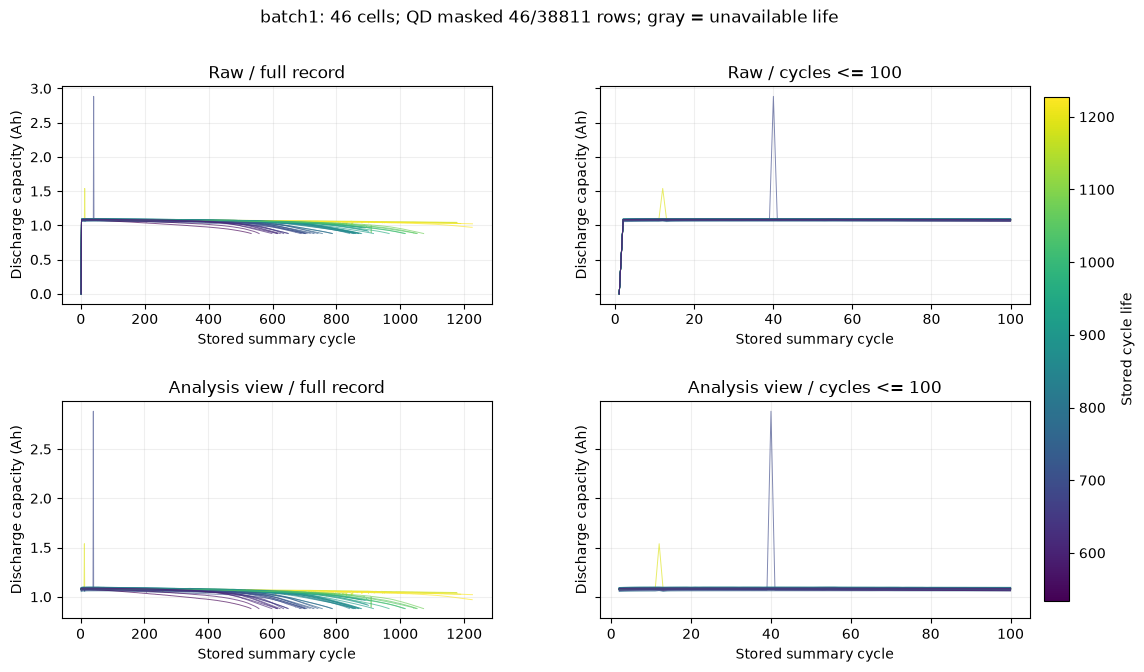

In [6]:
fig, axes = eda.plot_degradation_overview(prepared, cells, BATCH_NAME, EARLY_END)
if SAVE_FIGURES:
    output_dir = PROJECT_ROOT / "outputs/figures" / BATCH_NAME
    output_dir.mkdir(parents=True, exist_ok=True)
    mode = "high_qd_masked" if MASK_HIGH_QD else "conservative"
    fig.savefig(output_dir / f"degradation_overview_{mode}_early{EARLY_END}.png", dpi=140)
plt.show()
plt.close(fig)

## 6. 장·중·단수명 대표 셀 비교

수명 값이 있는 셀 중 각 그룹 중앙값에 가장 가까운 셀을 선택합니다. 동률은 cell_id로 정렬합니다. 단수명 <500, 장수명 >1000, 중간은 500–1000(양끝 포함)입니다. 그룹이 비어 있으면 빈 그룹으로 표시하고 대체 셀을 넣지 않습니다.

대표 셀은 그룹 평균이 아니며, 그래프만으로 인과관계나 전체 그룹 특성을 단정하지 않습니다.

전체 구간은 원본/분석용 곡선을 겹쳐 표시하고, 초기 확대는 분석용 곡선만 표시합니다. 초기 0값이 축 범위를 넓혀 작은 변화를 가리지 않도록 하며, 원본은 앞의 전체 개요와 표에서 확인합니다.

,batch,cell_id,cycle_life,life_group,group_cell_count,group_median_life
0,batch1,11,788.0,medium (500–1000),36,772.5
1,batch1,2,1177.0,long (>1000),10,1125.5


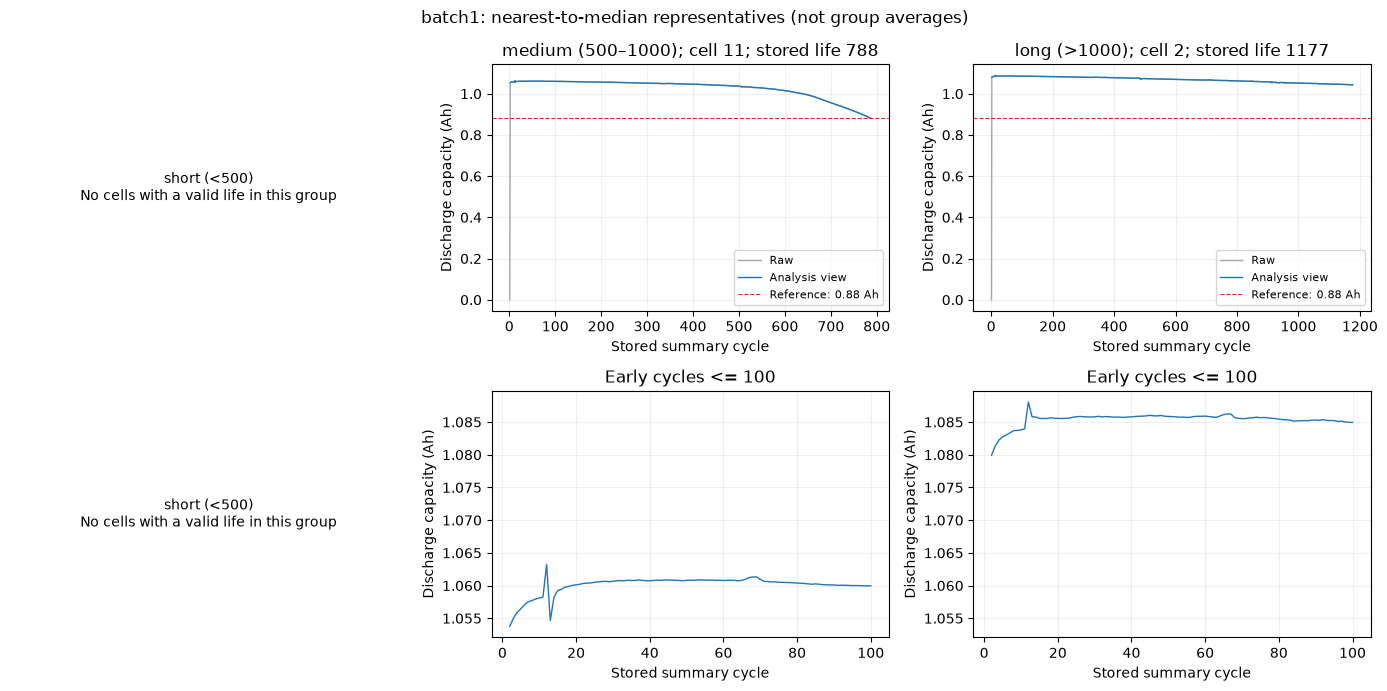

In [7]:
representatives = preprocess.representative_cells(cells)
display(representatives)
fig, axes = eda.plot_representatives(prepared, representatives, BATCH_NAME, EARLY_END,
                                    config.nominal_capacity_ah * config.eol_fraction)
if SAVE_FIGURES:
    fig.savefig(output_dir / f"representative_degradation_{mode}_early{EARLY_END}.png", dpi=140)
plt.show()
plt.close(fig)

## 7. 선택한 셀을 더 자세히 확인

위 조건에서 `MANUAL_CELL_IDS`를 설정하면 원하는 셀을 확인합니다. 아래 표에는 첫 12개와 마지막 5개 원본 회차가 나오며, 분석용 NaN이 적용된 위치도 함께 확인합니다.

In [8]:
selected_ids = representatives.cell_id.tolist() if MANUAL_CELL_IDS is None else MANUAL_CELL_IDS
for cid in selected_ids:
    if cid not in cells.cell_id.values:
        raise ValueError(f"Unknown cell_id: {cid}")
    sub = prepared.loc[prepared.cell_id.eq(cid)].sort_values("cycle")
    print(f"Cell {cid}; stored life: {sub.cycle_life.iloc[0]}")
    display(pd.concat([sub.head(12), sub.tail(5)])[
        ["cell_id", "cycle", "QD", "QD_analysis", "IR", "IR_analysis", "flag_after_life"]])
if MANUAL_CELL_IDS is not None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for cid in selected_ids:
        sub = prepared.loc[prepared.cell_id.eq(cid)].sort_values("cycle")
        for ax, part in zip(axes, [sub, sub.loc[sub.cycle.le(EARLY_END)]]):
            ax.plot(part.cycle, part.QD_analysis, label=f"Cell {cid}")
    for ax, title in zip(axes, ["Full record", f"Cycles <= {EARLY_END}"]):
        ax.set(title=title, xlabel="Stored summary cycle", ylabel="Discharge capacity (Ah)")
        ax.legend()
    fig.tight_layout()
    plt.show()
    plt.close(fig)

Cell 11; stored life: 788.0


,cell_id,cycle,QD,QD_analysis,IR,IR_analysis,flag_after_life
11407,11,1.0,0.000000,NaN,0.000000,NaN,False
11408,11,2.0,1.053779,1.053779,0.016575,0.016575,False
11409,11,3.0,1.055032,1.055032,0.016582,0.016582,False
11410,11,4.0,1.055879,1.055879,0.016588,0.016588,False
11411,11,5.0,1.056445,1.056445,0.016545,0.016545,False
11412,11,6.0,1.057079,1.057079,0.016491,0.016491,False
11413,11,7.0,1.057523,1.057523,0.016419,0.016419,False
11414,11,8.0,1.057707,1.057707,0.016341,0.016341,False
11415,11,9.0,1.057944,1.057944,0.016249,0.016249,False
11416,11,10.0,1.058100,1.058100,0.016196,0.016196,False


Cell 2; stored life: 1177.0


,cell_id,cycle,QD,QD_analysis,IR,IR_analysis,flag_after_life
2367,2,1.0,0.000000,NaN,0.000000,NaN,False
2368,2,2.0,1.079922,1.079922,0.016868,0.016868,False
2369,2,3.0,1.081315,1.081315,0.016832,0.016832,False
2370,2,4.0,1.082234,1.082234,0.016719,0.016719,False
2371,2,5.0,1.082731,1.082731,0.016715,0.016715,False
2372,2,6.0,1.083030,1.083030,0.016664,0.016664,False
2373,2,7.0,1.083339,1.083339,0.016675,0.016675,False
2374,2,8.0,1.083684,1.083684,0.016660,0.016660,False
2375,2,9.0,1.083715,1.083715,0.016701,0.016701,False
2376,2,10.0,1.083782,1.083782,0.016687,0.016687,False


## 8. 세 Batch에 같은 기준 적용

한 Batch씩 읽고 해제합니다. 수명 값이 없거나 관측 종료 전에 기준 도달이 확인되지 않은 셀도 원본 목록에 남깁니다. 원 논문의 연장·제외 규칙은 아직 적용하지 않았습니다.

In [9]:
batch_audit = []
for name in load_data.BATCH_FILES:
    c, s, _ = load_data.load_batch(load_data.batch_path(name, DATA_DIR), name)
    p = preprocess.prepare_summary(s, config)
    d = preprocess.cell_diagnostics(c, p, config)
    pd.testing.assert_frame_equal(s, p[s.columns])
    crossing = d.loc[np.isfinite(d.cycle_life) & np.isfinite(d.first_observed_cycle_le_eol)]
    batch_audit.append({
        "batch": name, "cells": len(c), "raw_rows": len(s),
        "QD_masked": p.QD_analysis.isna().sum(), "IR_masked": p.IR_analysis.isna().sum(),
        "high_QD_flagged": p.flag_qd_high.sum(),
        "all_zero_measurement_rows": p.flag_all_measurements_zero.sum(),
        "invalid_life_cells": d.flag_life_invalid_rows.gt(0).sum(),
        "known_life_observed_crossings": len(crossing),
        "crossings_matching_life": crossing.crossing_minus_life.eq(0).sum(),
        "after_life_rows": p.flag_after_life.sum(),
    })
    del c, s, p, d
batch_audit = pd.DataFrame(batch_audit)
display(batch_audit)

,batch,cells,raw_rows,QD_masked,IR_masked,high_QD_flagged,all_zero_measurement_rows,invalid_life_cells,known_life_observed_crossings,crossings_matching_life,after_life_rows
0,batch1,46,38811,46,65,2,46,0,0,0,0
1,batch2,47,26904,0,4904,11,0,8,39,39,970
2,batch3,46,51007,0,0,0,0,2,0,0,0


## 9. 관찰 기록

- 분석 조건: 선택한 Batch, 위 config, 초기 cycle 범위, 대표 셀 목록.
- 관찰: 실제 그래프와 표에서 확인한 사실.
- 가설: 관찰과 구분한 가능한 설명.
- 추가 질문: 높은 QD의 원인, 종료 시점과 타깃 정의, 동일 물리 셀의 실험 연장 여부.
- 열화 질문: 감소 속도가 일정한가? 특정 구간 이후 가속되는가? 초기만 보면 수명 그룹이 구분되는가?

현재는 knee point를 자동 확정하지 않습니다. 곡선 형태와 구간을 확인한 뒤 설명 가능한 방법을 선택합니다. 다음 분석은 상세 cycle 번호 대응을 검증하고 ΔQ(V)를 탐색하는 것입니다.

### 첫 실행 관찰 (2026-10-01)

- 기본 설정에서 원본 행은 모두 유지됐습니다. Batch 1의 QD=0인 cycle 1은 셀 46개 모두에서 나타났으며 QD 분석용 값만 NaN으로 표시했습니다.
- 높은 QD 검토 플래그는 Batch 1에서 2개, Batch 2에서 11개, Batch 3에서 0개입니다. 원인은 미확인이며 기본 그래프에는 남아 있습니다.
- Batch 2의 수명이 있는 39개 셀 모두에서 첫 QD ≤0.88 Ah 회차와 저장 수명이 일치합니다. 수명 이후에도 970개 행의 기록이 이어집니다.
- Batch 2의 셀 40–46은 전체 IR이 0이므로 IR 분석용 값이 모두 NaN입니다.
- Batch 1·3에는 수명 <500 셀이 없어 단수명 대표를 선택하지 않았습니다.
- Batch 2·3 대표 곡선에는 후기 용량 감소가 빨라지는 구간이 보입니다. Batch 2 대표의 초기 일시적 급락은 원인을 더 확인해야 합니다.
- Batch 1·3의 수명 있는 셀은 모두 기록 최대 cycle +1을 수명으로 가지고, 0.88 Ah 이하 QD의 관측은 없습니다. 저장 수명 정의를 셀별로 추가 확인해야 합니다.

조건·수치·외부 근거와 다음 질문은 `docs/day1/07_전처리_기준_및_첫_EDA_관찰.md`에 기록했습니다. 전체 열화 곡선에서 얻는 정보는 초기 수명 예측 입력과 구분합니다.